<a href="https://colab.research.google.com/github/jwe4/makemore_from_scratch/blob/main/build_makemore2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [56]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

### Upload `names.txt`
Please upload your `names.txt` file using the following cell. This will make the file accessible in your Colab environment.

In [57]:
from google.colab import files

uploaded = files.upload()

Saving names.txt to names (2).txt


Once uploaded, the file will typically be in the `/content/` directory. The next cell has been updated to reflect this.

In [58]:
#read in all the words
words = open('/content/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [59]:
len(words)

32033

In [60]:
# build the vocabulart of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [61]:
# build the dataset
block_size = 3 # context length: how any characters do we take to predict the next one
# X is input, Y is labels

X,Y = [],[]
for w in words[:5]:
  print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix= stoi[ch]
    X.append(context)
    Y.append(ix)
    print(''.join(itos[i] for i in context), '-->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

emma
... --> e
..e --> m
.em --> m
emm --> a
mma --> .
olivia
... --> o
..o --> l
.ol --> i
oli --> v
liv --> i
ivi --> a
via --> .
ava
... --> a
..a --> v
.av --> a
ava --> .
isabella
... --> i
..i --> s
.is --> a
isa --> b
sab --> e
abe --> l
bel --> l
ell --> a
lla --> .
sophia
... --> s
..s --> o
.so --> p
sop --> h
oph --> i
phi --> a
hia --> .


In [62]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([32, 3]), torch.int64, torch.Size([32]), torch.int64)

In [63]:
X

tensor([[ 0,  0,  0],
        [ 0,  0,  5],
        [ 0,  5, 13],
        [ 5, 13, 13],
        [13, 13,  1],
        [ 0,  0,  0],
        [ 0,  0, 15],
        [ 0, 15, 12],
        [15, 12,  9],
        [12,  9, 22],
        [ 9, 22,  9],
        [22,  9,  1],
        [ 0,  0,  0],
        [ 0,  0,  1],
        [ 0,  1, 22],
        [ 1, 22,  1],
        [ 0,  0,  0],
        [ 0,  0,  9],
        [ 0,  9, 19],
        [ 9, 19,  1],
        [19,  1,  2],
        [ 1,  2,  5],
        [ 2,  5, 12],
        [ 5, 12, 12],
        [12, 12,  1],
        [ 0,  0,  0],
        [ 0,  0, 19],
        [ 0, 19, 15],
        [19, 15, 16],
        [15, 16,  8],
        [16,  8,  9],
        [ 8,  9,  1]])

In [64]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [65]:
# the 27 character embedding
C = torch.randn((27,2))

In [66]:
C

tensor([[ 0.3432,  0.7882],
        [-0.8374,  0.4675],
        [ 0.2307,  0.4368],
        [-1.4670,  2.3682],
        [-0.0990, -0.9000],
        [-1.1083, -1.2768],
        [ 0.2979,  0.1920],
        [ 0.5057, -1.8194],
        [ 1.0213,  0.1161],
        [ 0.1546,  1.6664],
        [ 0.2018,  0.6313],
        [ 1.6473, -1.1814],
        [ 0.8333,  0.2742],
        [ 1.3585, -0.2548],
        [ 1.3807, -0.7641],
        [ 0.5747, -0.1227],
        [-0.4402,  1.5488],
        [-1.0197,  1.3270],
        [ 0.3261,  0.4620],
        [-0.9163, -1.1243],
        [-0.9319,  0.7168],
        [ 0.5396, -2.1279],
        [-0.2626,  0.5627],
        [ 0.5361, -0.1221],
        [-2.2710, -0.4266],
        [-0.8643, -0.8446],
        [ 1.1108, -0.5925]])

In [67]:
# encode an example integer( integers represent the characters)

F.one_hot(torch.tensor(5), num_classes=27)

tensor([0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0])

In [68]:
F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([-1.1083, -1.2768])

In [69]:
C[5]

tensor([-1.1083, -1.2768])

In [70]:
# will use index rather than one hot
# can index by X
C[X].shape

torch.Size([32, 3, 2])

In [71]:
X[13,2]

tensor(1)

In [72]:
C[X][13,2]
# Yes, the weight matrix W1 for the hidden layer is defined as (6, 100), meaning 6 rows and 100 columns.

tensor([-0.8374,  0.4675])

In [73]:
C[1]

tensor([-0.8374,  0.4675])

In [74]:
# so have embedding
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [75]:
# now building the hidden layer
W1 = torch.randn(6,100)
b1 = torch.randn(100)

In [76]:
emb[:,0,:].shape

torch.Size([32, 2])

In [77]:
emb[:,0,:]

tensor([[ 0.3432,  0.7882],
        [ 0.3432,  0.7882],
        [ 0.3432,  0.7882],
        [-1.1083, -1.2768],
        [ 1.3585, -0.2548],
        [ 0.3432,  0.7882],
        [ 0.3432,  0.7882],
        [ 0.3432,  0.7882],
        [ 0.5747, -0.1227],
        [ 0.8333,  0.2742],
        [ 0.1546,  1.6664],
        [-0.2626,  0.5627],
        [ 0.3432,  0.7882],
        [ 0.3432,  0.7882],
        [ 0.3432,  0.7882],
        [-0.8374,  0.4675],
        [ 0.3432,  0.7882],
        [ 0.3432,  0.7882],
        [ 0.3432,  0.7882],
        [ 0.1546,  1.6664],
        [-0.9163, -1.1243],
        [-0.8374,  0.4675],
        [ 0.2307,  0.4368],
        [-1.1083, -1.2768],
        [ 0.8333,  0.2742],
        [ 0.3432,  0.7882],
        [ 0.3432,  0.7882],
        [ 0.3432,  0.7882],
        [-0.9163, -1.1243],
        [ 0.5747, -0.1227],
        [-0.4402,  1.5488],
        [ 1.0213,  0.1161]])

In [78]:
torch.cat([emb[:,0,:], emb[:,1,:],emb[:,2,:]],1).shape

torch.Size([32, 6])

In [79]:
# can do something similar with unbind
torch.cat(torch.unbind(emb,1),1).shape

torch.Size([32, 6])

In [80]:
# still another approach
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [81]:
a.shape

torch.Size([18])

In [82]:
a.view(9,2) # view is very efficient

tensor([[ 0,  1],
        [ 2,  3],
        [ 4,  5],
        [ 6,  7],
        [ 8,  9],
        [10, 11],
        [12, 13],
        [14, 15],
        [16, 17]])

In [83]:
emb.shape

torch.Size([32, 3, 2])

In [84]:
emb.view(32,6) == torch.cat(torch.unbind(emb,1),1)
#


tensor([[True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, True, True],
        [True, True, True, True, T

In [85]:
# back to the hidden layer interface
W1 = torch.randn(6,100)
b1 = torch.randn(100)
h = emb.view(32,6) @ W1 + b1
h.shape

torch.Size([32, 100])

In [86]:
# h = emb.view(emb.shape[0], 6) @W1 + b1
# equivalently, pytorch will infer 32 since it knows the dimensions of W1 + b1
h = emb.view(-1,6) @ W1 + b1

In [87]:
h.shape

torch.Size([32, 100])

In [88]:
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # to make probabilities

In [89]:
h

tensor([[-0.3822,  0.4793, -0.8010,  ...,  0.1045, -0.4999, -0.3909],
        [-0.9038, -0.9979, -0.9989,  ..., -0.9975, -0.9974,  0.9968],
        [ 0.9994,  0.4912,  0.9253,  ...,  0.8845, -0.0709, -1.0000],
        ...,
        [-0.4180,  0.9551,  0.9813,  ...,  0.0824, -0.6481,  0.8776],
        [ 0.2346,  0.4562, -0.9981,  ...,  0.6243, -0.0825, -0.9976],
        [-0.9959, -0.9034, -0.5910,  ..., -0.7889, -0.7354,  0.9998]])

In [90]:
h.shape

torch.Size([32, 100])

In [91]:
# with regard to W1 + b1
# have broadcasting
# 32, 100
#     100

# this results in align on right and creating a 1 on the left
# 1 1000 -- creates a 1 x 100 row that gets added as a column to each of the 32

W2 = torch.randn(100,27)
b2 = torch.randn(27)

logits = h @ W2 + b2


In [92]:
logits.shape

torch.Size([32, 27])

In [93]:
counts = logits.exp()


In [94]:
prob = counts / counts.sum(1,keepdims=True)

In [95]:
prob.shape

torch.Size([32, 27])

In [96]:
prob[0].sum()

tensor(1.)

In [97]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [98]:
# now to get the negative log likelihood loss by comparing with the probabilites in Y
prob[torch.arange(32),Y]


tensor([3.3670e-04, 3.5952e-06, 2.4932e-03, 8.2076e-12, 7.3850e-08, 1.6610e-05,
        6.9474e-07, 6.6233e-07, 9.4721e-17, 1.5247e-03, 1.4216e-10, 2.1253e-12,
        7.4514e-10, 1.5806e-05, 1.4838e-08, 2.1574e-15, 7.1997e-03, 5.9013e-14,
        1.1388e-09, 1.7532e-06, 3.0621e-06, 1.3002e-10, 1.1021e-08, 3.4692e-08,
        5.0113e-08, 2.5666e-09, 3.8713e-07, 7.3502e-08, 6.2085e-07, 4.2185e-01,
        9.9420e-10, 8.5749e-08])

In [99]:
loss = -prob[torch.arange(32),Y].log().mean()
loss

tensor(17.0258)

In [100]:
# ---- now made respectab le :) ----

In [101]:
X.shape, Y.shape # dataset

(torch.Size([32, 3]), torch.Size([32]))

In [102]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g) # Added generator=g here
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [103]:
sum(p.nelement() for p in parameters) # number of parameters in total

3481

In [104]:
emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2  # (32,27)
counts = logits.exp()
prob = counts / counts.sum(1, keepdims=True)
loss = -prob[torch.arange(32), Y].log().mean()
loss


tensor(17.7697)

In [105]:
F.cross_entropy(logits, Y) # can use builtin function for this, it is more efficient

tensor(17.7697)

In [106]:
emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2  # (32,27)
F.cross_entropy(logits, Y)
loss
# don't need to create the intermediate tensors, runs in a fused kernel

tensor(17.7697)

In [107]:
# can have problems like this in extreme cases
# caused by problems with floating point range
# pytorch calculates the greatest number and subtracts it
# doesn't affect the accuracy
logits = torch.tensor([-100,-3,0,100])
counts = logits.exp()
probs = counts/counts.sum()
probs

tensor([0., 0., 0., nan])

In [108]:
# build the dataset again for all the words
block_size = 3 # context length: how any characters do we take to predict the next one
# X is input, Y is labels

X,Y = [],[]
for w in words:
  # print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix= stoi[ch]
    X.append(context)
    Y.append(ix)
    # print(''.join(itos[i] for i in context), '-->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [109]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [120]:
# re-initialize the weights
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g) # Added generator=g here
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [111]:
for p in parameters:
  p.requires_grad = True

In [112]:

for _ in range(10):
  #forward pass

  emb = C[X] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2  # (32,27)
  loss = F.cross_entropy(logits, Y)
  print(loss.item())
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  #update
  for p in parameters:
    p.data += -0.1 * p.grad

19.505226135253906
17.08449363708496
15.776531219482422
14.833340644836426
14.002603530883789
13.253260612487793
12.57991886138916
11.983101844787598
11.47049331665039
11.051856994628906


In [113]:
torch.randint(0, X.shape[0], (32,))

tensor([ 78541,  35569, 218452,  74673,  12379, 118229, 105261, 224018, 150269,
         91676, 187618, 163419, 127460,  96620,  77934, 195637, 181659,  54997,
        117494, 196797,  44210,  19866, 157774, 218035,  64791,  16793, 198390,
         85948, 153200, 133181, 120382,  80989])

In [114]:
torch.randint(0, X.shape[0], (32,))

tensor([ 73788, 151953, 171131, 157022,  54651, 215302, 148802,  52309, 139357,
         48172, 162942, 149231, 131087,  70289,  41885, 111786, 195279,  80580,
        153633, 150329,  85390,  62767, 170256,   5589,  84498, 134733,  55401,
        120687,  97267, 109960,  90858, 133993])

In [115]:
for _ in range(1000):
  #forward pass
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))

  # only get a mini batch
  emb = C[X[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2  # (32,27)
  loss = F.cross_entropy(logits, Y[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  #update
  for p in parameters:
    p.data += -0.1 * p.grad

print(loss.item())

3.0475518703460693


In [116]:
# now evaluate total loss after mini batches
emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.7254, grad_fn=<NllLossBackward0>)

In [135]:
# re-initialize the weights copied from above for clarity
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2), generator=g)
W1 = torch.randn((6, 100), generator=g)
b1 = torch.randn(100, generator=g) # Added generator=g here
W2 = torch.randn((100,27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

for p in parameters:
  p.requires_grad = True

In [132]:
# now adjusting learning rate

lre = torch.linspace(-3, 0, 1000)
lrs = 10 ** lre

In [133]:

lri = []
lossi = []

for i in range(1000):
  #forward pass
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))

  # only get a mini batch
  emb = C[X[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2  # (32,27)
  loss = F.cross_entropy(logits, Y[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  #update
  lr = lrs[i]
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  lri.append(lre[i])
  lossi.append(loss.item())

print(loss.item())

9.129057884216309


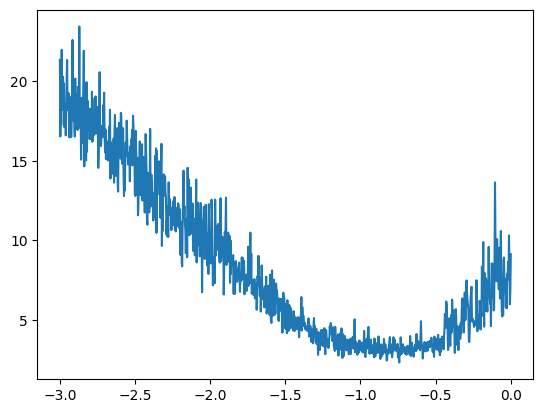

In [134]:
plt.plot(lri, lossi)

In [ ]:
# lr = 0.1 looks best, see -1.0 at bottom of curve

In [142]:


for i in range(10000):
  #forward pass
  # minibatch construct
  ix = torch.randint(0, X.shape[0], (32,))

  # only get a mini batch
  emb = C[X[ix]] # (32,3,2)
  h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2  # (32,27)
  loss = F.cross_entropy(logits, Y[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  #update
  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad


# print(loss.item())

In [143]:
# now evaluate total loss after mini batches
emb = C[X] # (32,3,2)
h = torch.tanh(emb.view(-1,6) @ W1 + b1) # (32,100)
logits = h @ W2 + b2 # (32,27)
loss = F.cross_entropy(logits, Y)
loss

tensor(2.3682, grad_fn=<NllLossBackward0>)

In [ ]:
# after this can decrease/decay the learning rate

In [ ]:
# split data into training, dev/validation split, test split
# 80%, 10%, 10%
# train data, train parameters, test the training